<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Camilo Rendon
-Nicolas Cubillos
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [20]:
### TU CÓDIGO AQUÍ ###
import os
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [21]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
path = '/content/drive/MyDrive/bases ia'
# Para establecer el directorio de los archivos
os.chdir(path)

In [24]:
df = pd.read_csv('/content/drive/MyDrive/bases ia/Indicators.csv')

In [25]:
### TU CÓDIGO AQUÍ ###
df_indicators = df.copy()
df_indicators.head()

,CountryCode,IndicatorCode,Year,Value
0,CHL,NV.AGR.TOTL.ZS,2014,6.75
1,CHL,NE.TRD.GNFS.ZS,2014,74.31
2,CHL,NY.GDP.MKTP.KD.ZG,2014,7.65
3,CHL,FP.CPI.TOTL.ZG,2014,12.62
4,CHL,GC.DOD.TOTL.GD.ZS,2014,42.83


In [26]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [27]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [28]:
dfb = pd.read_csv('/content/drive/MyDrive/bases ia/Country.csv')

In [29]:
### TU CÓDIGO AQUÍ ###
df_countries = dfb.copy()
df_countries.head()

,CountryCode,ShortName,Region
0,CHL,Chile,Latin America & Caribbean
1,PAN,Panamá,Latin America & Caribbean
2,CRI,Costa Rica,Latin America & Caribbean
3,COL,Colombia,Latin America & Caribbean
4,PER,Perú,Latin America & Caribbean


In [30]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [31]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [32]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [33]:
### TU CÓDIGO AQUÍ ###
df_indicators['IndicatorCode'] = df_indicators['IndicatorCode'].map(nombre_indicadores)

2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [34]:
### TU CÓDIGO AQUÍ ###
df_pivot = df_indicators.pivot_table(index='CountryCode', columns='IndicatorCode', values='Value').reset_index()
df_pivot.head()

IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [35]:
### TU CÓDIGO AQUÍ ###
df_final = pd.merge(df_pivot, df_countries, on='CountryCode')
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [36]:
### TU CÓDIGO AQUÍ ###
df_final = df_final.drop(columns=['Region', 'CountryCode'])
df_final = df_final.set_index('ShortName')
df_final

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61
Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49
Germany,NaN,NaN,1.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ecuador,10.88,54.23,1.82,63.47,739.26,"45,656,553,608.63",3.49,3.89,6.18,"39,525,318,329.77",28.66
México,9.27,49.22,4.85,52.55,614.33,"64,056,943,191.53",4.36,5.48,NaN,"59,903,958,738.66",15.52


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [37]:
### TU CÓDIGO AQUÍ ###
df_final.isnull().sum()

,0
Agricultura (% del PIB),4
Comercio (% del PIB),3
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),4
Días para cumplir contratos,2
Exportaciones (US$),3
Facilidad para hacer negocios,5
Gasto en educación (% del PIB),3
Gasto en salud (% del PIB),4
Importaciones (US$),3


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [38]:
### TU CÓDIGO AQUÍ ###
df_final_imputed = df_final.copy()
for col in df_final_imputed.columns:
    df_final_imputed[col].fillna(df_final_imputed[col].mean(), inplace=True)

In [39]:
df_final_imputed

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,8.86,54.39,1.76,66.69,798.96,"39,036,984,373.93",3.96,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61
Costa Rica,8.11,70.86,5.88,58.75,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49
Germany,8.86,56.08,1.90,58.75,700.28,"56,527,087,039.04",3.96,5.17,6.24,"51,667,740,842.74",22.59
Ecuador,10.88,54.23,1.82,63.47,739.26,"45,656,553,608.63",3.49,3.89,6.18,"39,525,318,329.77",28.66
México,9.27,49.22,4.85,52.55,614.33,"64,056,943,191.53",4.36,5.48,6.24,"59,903,958,738.66",15.52


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

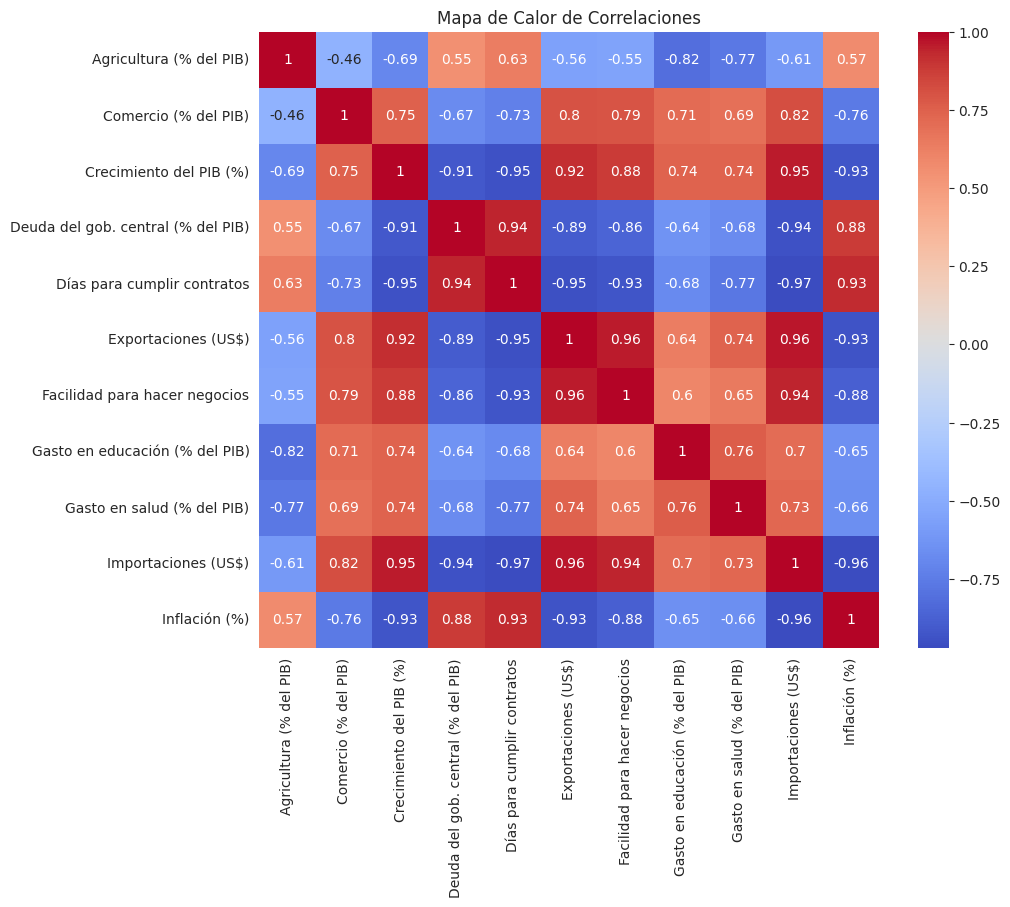

In [40]:
### TU CÓDIGO AQUÍ #
plt.figure(figsize=(10, 8))
sns.heatmap(df_final_imputed.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

Las correlaciones más importantes son las más cercanas a 1 o -1. Destacan las positivas entre exportaciones e importaciones (0.96), exportaciones y facilidad para hacer negocios (0.96), crecimiento del PIB e importaciones (0.95), facilidad para hacer negocios e importaciones (0.94) y deuda pública con días para cumplir contratos (0.94). Por el lado negativo, resaltan días para cumplir contratos e importaciones (-0.97), importaciones e inflación (-0.96), días para cumplir contratos y exportaciones (-0.95), crecimiento del PIB y días para cumplir contratos (-0.95) y deuda pública e importaciones (-0.94). En conjunto, estas relaciones muestran que mayor apertura económica y facilidad para hacer negocios se asocian con mejores condiciones de inversión, mientras que inflación, deuda y demoras contractuales se relacionan con un clima menos favorable.


4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [41]:
from re import X
### TU CÓDIGO AQUÍ ###
X_scaled = (df_final_imputed - df_final_imputed.mean()) / df_final_imputed.std()
X_scaled.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,1.51,-2.24,-1.50,1.37,1.59,-1.62,-1.40,-2.71,-2.09,-1.62,1.61
Bolivia,-0.00,-0.16,-0.68,0.76,0.91,-0.78,0.00,0.19,-1.16,-0.71,1.00
Brasil,2.07,0.39,-0.37,-0.15,0.38,-0.02,-0.31,-0.59,-0.91,-0.08,0.22
Chile,-1.11,1.73,1.51,-1.52,-1.51,1.51,1.52,1.18,1.98,1.39,-0.74
Colombia,-1.02,0.37,1.12,-1.03,-0.61,0.00,0.00,1.14,0.05,0.76,-0.81


### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [42]:
### TU CÓDIGO AQUÍ ###
V = X_scaled.values
pca = PCA()
pca.fit(V)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

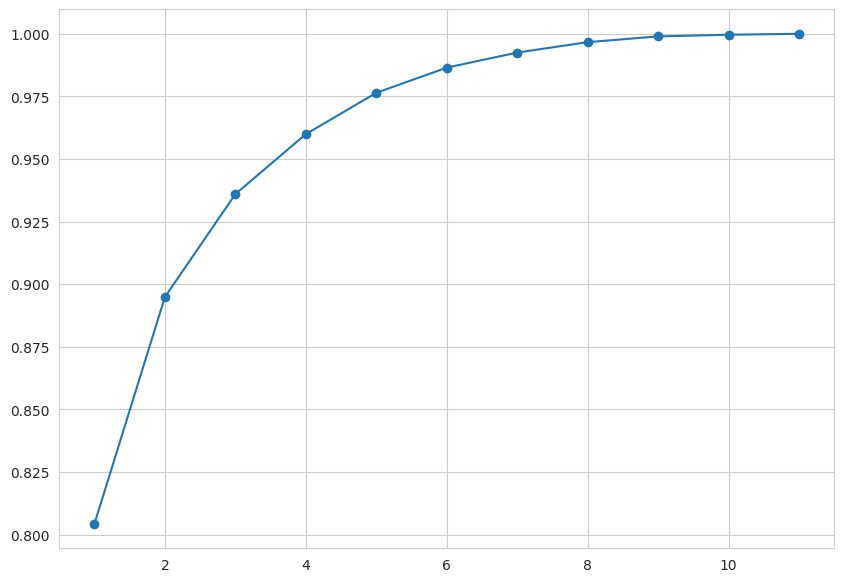

In [43]:
### TU CÓDIGO AQUÍ ###
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-')

5.3. Realiza un análisis del gráfico anterior.

La gráfica muestra que el **primer componente ya explica una proporción muy alta de la información**, alrededor de **80%**, y que al agregar más componentes la explicación acumulada aumenta rápidamente hasta acercarse al **100%**. El mayor salto ocurre entre los primeros componentes, especialmente del 1 al 3, lo que indica que estos concentran la mayor parte de la variabilidad de los datos. A partir del componente 6 o 7, la curva se vuelve casi plana, es decir, cada componente adicional aporta muy poca información nueva. Por eso, para construir un índice sintético del clima de inversión, usar el **componente 1** parece razonable, porque resume gran parte de la información, aunque si se quisiera una representación más completa podrían considerarse los primeros 2 o 3 componentes.


### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [44]:
### TU CÓDIGO AQUÍ ###
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(V)

6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

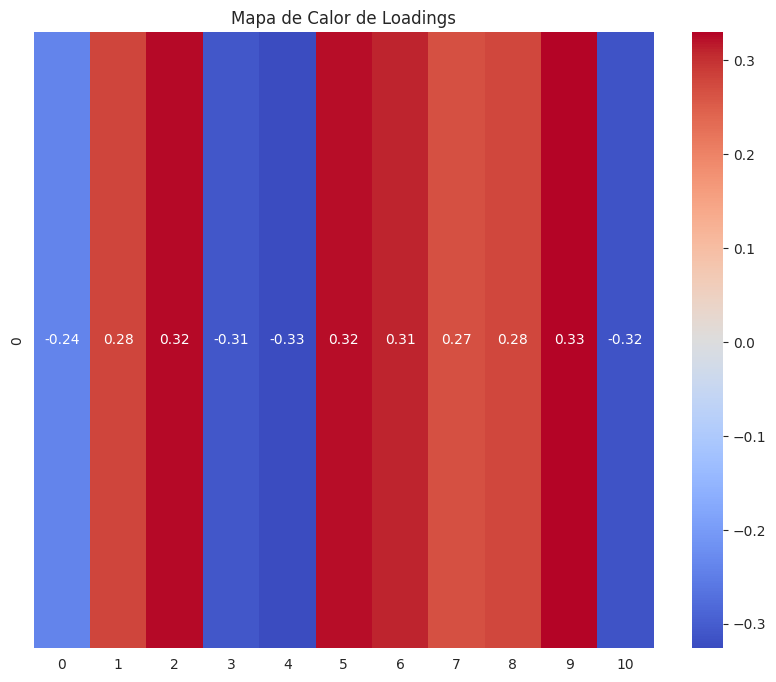

In [45]:
### TU CÓDIGO AQUÍ ###
plt.figure(figsize=(10, 8))
sns.heatmap(pca_final.components_, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Loadings')
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

Los loadings muestran que las variables con mayor carga positiva son la **9, 5, 2 y 6**, con valores cercanos a **0.31–0.33**, seguidas por la **1, 7 y 8**, que también aportan positivamente. Por el contrario, las cargas negativas más fuertes están en las variables **4, 10 y 3**, con valores cercanos a **-0.31 y -0.33**, además de la variable **0**, aunque con menor intensidad. En general, sí se podría usar el **componente 1 como índice de clima para la inversión**, porque resume el comportamiento conjunto de varias variables importantes; sin embargo, debe hacerse con cuidado, ya que algunas variables aportan en sentido positivo y otras en sentido negativo. Por eso, es clave verificar que las variables positivas representen condiciones favorables para invertir y que las negativas reflejen riesgos o barreras, para que el índice tenga una interpretación clara.


### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [46]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,-5.72
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,-1.86
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,-1.20
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.72
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.05


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [47]:
### TU CÓDIGO AQUÍ ###
df_final = df_final.sort_values(by='Indice_Inversion', ascending=False)

In [48]:
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.72
Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.75
Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.65
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.05
Uruguay,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,1.05


7.2. Convierte 'ShortName' en una columna del dataframe.

In [49]:
### TU CÓDIGO AQUÍ ###
df_final.reset_index(inplace=True)
df_final.head()

,ShortName,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
0,Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,4.72
1,Panamá,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,3.75
2,Costa Rica,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,2.65
3,Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,2.05
4,Uruguay,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,1.05


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

Text(0.5, 1.0, 'Índice de Clima para la Inversión')

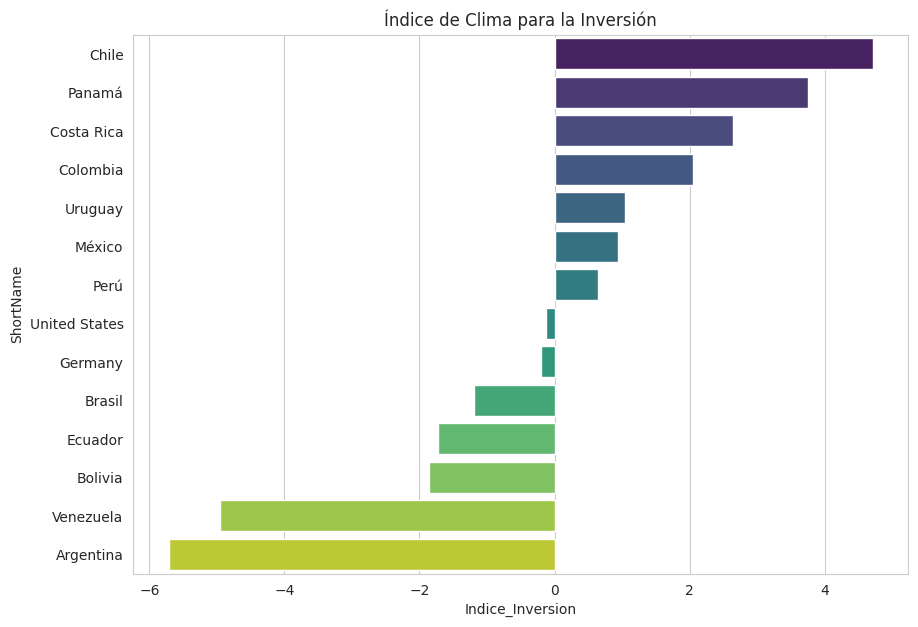

In [50]:
### TU CÓDIGO AQUÍ ###
plt.figure(figsize=(10, 7))
sns.barplot(x='Indice_Inversion', y='ShortName', data=df_final, palette='viridis')
plt.title('Índice de Clima para la Inversión')

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

Como asesores del MinTIC, este índice muestra que Colombia tiene un clima de inversión positivo, ubicado por encima del promedio y detrás de referentes regionales como Chile, Panamá y Costa Rica. Esto indica una oportunidad importante para fortalecer la atracción de inversión en tecnología, conectividad e innovación digital, pero también evidencia que aún hay margen para mejorar frente a países líderes. La recomendación sería consolidar la confianza inversionista mediante reglas claras, incentivos a la infraestructura digital, seguridad jurídica, talento TIC y simplificación de trámites, para que Colombia avance hacia una posición más competitiva en la región.
